# Ch.02-02 데이터 전처리

**노드:** N10 train_test_split · N11 스케일링 · N12 (결측/인코딩은 다음)

1. **train / test 분리** — 모의고사
2. **스케일링** — feature 단위가 다를 때 거리 왜곡 (Ch.1 k-NN)
3. **올바른 순서** — split → **train으로만** fit → train·test transform


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
rng = np.random.default_rng(42)


## 1) 샘플 데이터 — 생선 (길이 cm · 무게 g)

In [2]:
X = np.array([
    [25, 150], [26, 145], [24, 155], [27, 148],   # 빙어
    [28, 200], [30, 180], [29, 210], [31, 195],   # 도미
    [25, 152], [26, 140], [28, 205], [30, 190],
])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1])  # 0=빙어, 1=도미
feature_names = ["길이 (cm)", "무게 (g)"]
print("X.shape:", X.shape)


X.shape: (12, 2)


## 2) train_test_split — **연습 vs 모의고사**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("train:", X_train.shape[0], "마리 · test:", X_test.shape[0], "마리")
print("y_train:", y_train, "\ny_test:", y_test)


train: 9 마리 · test: 3 마리
y_train: [0 0 1 1 0 1 1 0 1] 
y_test: [1 0 0]


(12, 2)는 생선 12마리 × 특징 2개라는 뜻입니다.

np.array([...])에 넣은 값은 생선을 한 줄씩 적은 표입니다.

┌────┬───────────┬──────────┬────────┐
│    │ 길이 (cm) │ 무게 (g) │ 정답 y │
├────┼───────────┼──────────┼────────┤
│ 1  │        25 │      150 │ 빙어   │
├────┼───────────┼──────────┼────────┤
│ 2  │        26 │      145 │ 빙어   │
├────┼───────────┼──────────┼────────┤
│ 3  │        24 │      155 │ 빙어   │
├────┼───────────┼──────────┼────────┤
│ 4  │        27 │      148 │ 빙어   │
├────┼───────────┼──────────┼────────┤
│ 5  │        28 │      200 │ 도미   │
├────┼───────────┼──────────┼────────┤
│ 6  │        30 │      180 │ 도미   │
├────┼───────────┼──────────┼────────┤
│ 7  │        29 │      210 │ 도미   │
├────┼───────────┼──────────┼────────┤
│ 8  │        31 │      195 │ 도미   │
├────┼───────────┼──────────┼────────┤
│ 9  │        25 │      152 │ 빙어   │
├────┼───────────┼──────────┼────────┤
│ 10 │        26 │      140 │ 빙어   │
├────┼───────────┼──────────┼────────┤
│ 11 │        28 │      205 │ 도미   │
├────┼───────────┼──────────┼────────┤
│ 12 │        30 │      190 │ 도미   │
└────┴───────────┴──────────┴────────┘

• 12 = 행 = 샘플 수. [25, 150] 같은 쌍이 12개라서입니다.
• 2 = 열 = feature 수. 각 생선마다 길이·무게 두 숫자만 있어서입니다.

코드 주석과 y를 맞춰 보면 빙어 6마리, 도미 6마리입니다. 세 번째 줄 네 마리는 주석이 없지만 y의 마지막 [0, 0, 1, 1]이 빙어·빙어·도미·도미입니다.

그래서 X[0]은 첫 생선 [25, 150], X[:, 0]은 길이 열 전체, X[:, 1]은 무게 열 전체입니다. y 길이도 12여야 X의 각 행과 짝이 맞습니다.

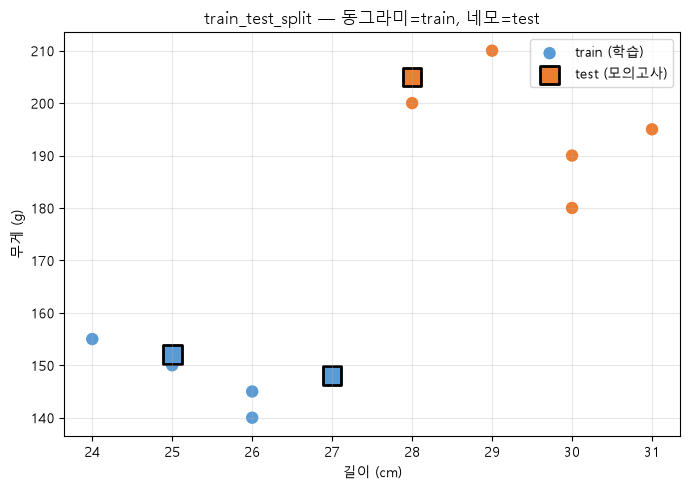

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_train[:, 0], X_train[:, 1], c=["#5B9BD5" if v == 0 else "#ED7D31" for v in y_train],
           s=120, marker="o", edgecolors="white", linewidths=2, label="train (학습)")
ax.scatter(X_test[:, 0], X_test[:, 1], c=["#5B9BD5" if v == 0 else "#ED7D31" for v in y_test],
           s=180, marker="s", edgecolors="black", linewidths=2, label="test (모의고사)")
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.set_title("train_test_split — 동그라미=train, 네모=test")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3) 스케일 문제 — **무게 차이가 거리를 지배**

길이 3cm 차이 vs 무게 50g 차이 — 숫자 크기가 다르면 k-NN은 **무게만** 본다.

In [5]:
a = np.array([25, 150])
b = np.array([28, 150])  # 길이만 3cm 다름
c = np.array([25, 200])  # 무게만 50g 다름

def dist(p, q):
    return np.sqrt(((p - q) ** 2).sum())

print(f"길이 3cm 차이 거리: {dist(a, b):.1f}")
print(f"무게 50g 차이 거리: {dist(a, c):.1f}")
print("→ 스케일 안 맞추면 '50'이 '3'보다 훨씬 멀리 느껴짐")


길이 3cm 차이 거리: 3.0
무게 50g 차이 거리: 50.0
→ 스케일 안 맞추면 '50'이 '3'보다 훨씬 멀리 느껴짐


## 4) StandardScaler — **train 평균·표준편차로 맞춤**

$$z = \frac{x - \mu_{train}}{\sigma_{train}}$$

**규칙:** `scaler.fit(X_train)` 만 · test 정보는 **절대** fit에 넣지 않음 (모의고사 답 leak)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # train에서 구한 μ, σ만 사용

print("train 원본 mean:", X_train.mean(axis=0))
print("train 원본 std :", X_train.std(axis=0, ddof=0))
print("scaled train mean (~0):", X_train_scaled.mean(axis=0).round(3))
print("scaled train std  (~1):", X_train_scaled.std(axis=0, ddof=0).round(3))


train 원본 mean: [ 27.66666667 173.88888889]
train 원본 std : [ 2.3570226  25.03084517]
scaled train mean (~0): [-0.  0.]
scaled train std  (~1): [1. 1.]


한 줄씩

scaler = StandardScaler()

빈 계산기입니다. 아직 μ(평균), σ(표준편차)는 없습니다.

X_train_scaled = scaler.fit_transform(X_train)

두 일을 한 번에 합니다.

1. fit — train만 보고 열마다 μ, σ를 구한다
2. transform — 그 숫자로 train을 z = (x−μ)/σ 로 바꾼다

지금 데이터에서는:

┌──────────────────┬──────────┬──────────┐
│                  │     길이 │     무게 │
├──────────────────┼──────────┼──────────┤
│ train 평균 μ     │ 27.67 cm │ 173.89 g │
├──────────────────┼──────────┼──────────┤
│ train 표준편차 σ │  2.36 cm │  25.03 g │
└──────────────────┴──────────┴──────────┘

첫 train 생선 [25, 150]은 이렇게 바뀝니다.

  (25−27.67)/2.36 ≈ −1.13,  (150−173.89)/25.03 ≈ −0.95

“길이 25cm, 무게 150g”이 아니라 **“길이 평균보다 1.13σ 작고, 무게 평균보다 0.95σ 작다”**가 됩니다.

X_test_scaled = scaler.transform(X_test)

fit은 다시 하지 않습니다. test의 평균을 쓰면 모의고사 답을 미리 보는 것과 같습니다. train에서 구한 μ, σ만 씁니다.

test 첫 마리 [28, 205]:

  (28−27.67)/2.36 ≈ 0.14,  (205−173.89)/25.03 ≈ 1.24

print가 확인하는 것

┌───────────────────┬────────────────┬──────────────────────────────────┐
│ 출력              │ 의미           │ 기대값                           │
├───────────────────┼────────────────┼──────────────────────────────────┤
│ train 원본 mean   │ 맞추기 전 평균 │ [27.67, 173.89] — 단위가 다름    │
├───────────────────┼────────────────┼──────────────────────────────────┤
│ train 원본 std    │ 맞추기 전 퍼짐 │ [2.36, 25.03] — 무게가 훨씬 넓음 │
├───────────────────┼────────────────┼──────────────────────────────────┤
│ scaled train mean │ 맞춘 뒤 평균   │ 대략 [0, 0]                      │
├───────────────────┼────────────────┼──────────────────────────────────┤
│ scaled train std  │ 맞춘 뒤 퍼짐   │ 대략 [1, 1]                      │
└───────────────────┴────────────────┴──────────────────────────────────┘

axis=0은 열 방향입니다. 길이끼리 평균, 무게끼리 평균을 냅니다. ddof=0은 sklearn과 같이 나눗셈을 n으로 합니다.

원본에서 무게 σ(25)가 길이 σ(2.4)보다 커서 거리가 무게에 먹혔습니다. 맞춘 뒤에는 두 열 모두 “표준편차 1칸”이라, 앞 셀의 dist가 길이·무게를 같은 비중으로 봅니다.

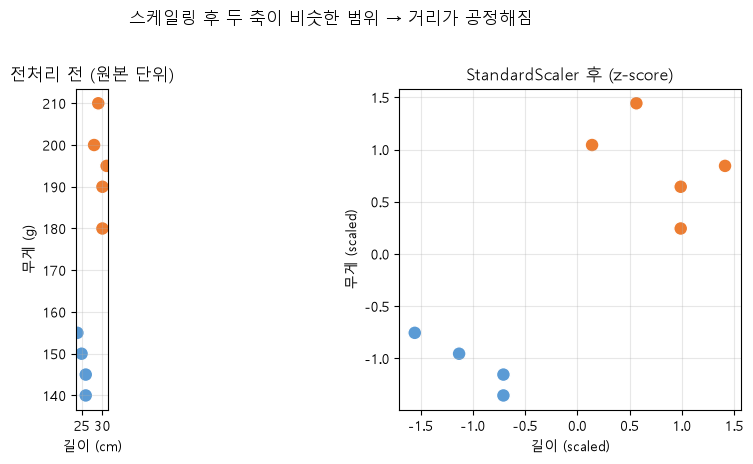

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, data, title in [
    (axes[0], X_train, "전처리 전 (원본 단위)"),
    (axes[1], X_train_scaled, "StandardScaler 후 (z-score)"),
]:
    ax.scatter(data[:, 0], data[:, 1], c=["#5B9BD5" if v == 0 else "#ED7D31" for v in y_train], s=100, edgecolors="white")
    ax.set_xlabel(feature_names[0] if "전" in title else "길이 (scaled)")
    ax.set_ylabel(feature_names[1] if "전" in title else "무게 (scaled)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

plt.suptitle("스케일링 후 두 축이 비슷한 범위 → 거리가 공정해짐", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 5) k-NN — 스케일링 전 vs 후 **test 정확도**

In [ ]:
def acc(y_true, y_pred):
    return (y_true == y_pred).mean()

knn_raw = KNeighborsClassifier(n_neighbors=3)
knn_raw.fit(X_train, y_train)
pred_raw = knn_raw.predict(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=3)
knn_scaled.fit(X_train_scaled, y_train)
pred_scaled = knn_scaled.predict(X_test_scaled)

print("test accuracy (스케일링 X):", acc(y_test, pred_raw))
print("test accuracy (StandardScaler):", acc(y_test, pred_scaled))


## 6) 전처리 파이프라인 (기억할 순서)

```text
1. train_test_split(X, y)
2. scaler.fit(X_train)          ← train만
3. X_train_s = transform(train)
4. X_test_s  = transform(test)  ← 같은 scaler
5. model.fit(X_train_s, y_train)
6. model.predict(X_test_s)
```

**다음 (02-3):** 결측치 · 원-핫 인코딩 · `Pipeline`